# 🌍 Life Expectancy Prediction — Regresión con PyTorch
## Reto proyecto 1 · Construye una red neuronal feed-forward para predecir la esperanza de vida
---
Este notebook entrena una red neuronal feed-forward para predecir la **esperanza de vida** de diferentes países  
usando el dataset *Life Expectancy (WHO)* de la Organización Mundial de la Salud.

| Paso | Descripción |
|------|-------------|
| 1️⃣ | Carga y exploración del dataset |
| 2️⃣ | Limpieza y preparación de datos |
| 3️⃣ | División, normalización y conversión a tensores |
| 4️⃣ | Construcción de la red neuronal (Feed-Forward, 2 capas ocultas + ReLU) |
| 5️⃣ | Entrenamiento con MSELoss + Adam + Weight Decay |
| 6️⃣ | Curva de aprendizaje y evaluación en el conjunto de prueba |

> **Dataset:** `dataset.csv` — 2938 registros · 22 columnas  
> **Objetivo:** predecir `Life_expectancy` (años, variable continua)  
> **Ruta:** `/workspace/dataset.csv`

---
## 📦 Paso 1 — Importación de librerías

In [19]:
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print(f"Pandas version  : {pd.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device          : {device}")

PyTorch version : 2.10.0+cpu
Pandas version  : 3.0.1
Device          : cpu


---
## 📂 Paso 2 — Carga y exploración del dataset

In [20]:
# Ruta absoluta tal como indica el enunciado.
# Opcionalmente se puede sobreescribir con la variable de entorno DATA_PATH
# para facilitar ejecución en otros entornos sin modificar el código:
#   export DATA_PATH=/otro/directorio/dataset.csv
import os
DATA_PATH = os.environ.get("DATA_PATH", "workspace/dataset.csv")

df = pd.read_csv(DATA_PATH)

print(f"Ruta utilizada   : {DATA_PATH}")
print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras filas:")
df.head()

Ruta utilizada   : workspace/dataset.csv
Forma del dataset: (2938, 22)

Primeras filas:


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [21]:
print("Tipos de datos:")
print(df.dtypes)
print("\nEstadísticas descriptivas:")
df.describe()

Tipos de datos:
Country                                str
Year                                 int64
Status                                 str
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
 BMI                               float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
 HIV/AIDS                          float64
GDP                                float64
Population                         float64
 thinness  1-19 years              float64
 thinness 5-9 years                float64
Income composition of resources    float64
Schooling                          float64
dtype: object

Estadísticas descriptiv

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [22]:
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


---
## 🧹 Paso 3 — Limpieza y preprocesamiento de datos

In [23]:
# Normalización de nombres de columnas en dos pasos:
# 1. str.strip()  → elimina espacios iniciales y finales
# 2. str.replace(r"\s+", "_", regex=True) → reemplaza espacios internos
#    (incluidos múltiples consecutivos) por guiones bajos.
#    Esto es necesario porque el dataset contiene columnas como
#    " BMI " o "Life expectancy " que str.strip() solo dejaría
#    como "BMI" y "Life expectancy" pero NO resolvería columnas
#    con espacios internos como " thinness  1-19 years".
df.columns = df.columns.str.strip().str.replace(r"\s+", "_", regex=True)

print("Columnas tras normalización:")
print(df.columns.tolist())

Columnas tras normalización:
['Country', 'Year', 'Status', 'Life_expectancy', 'Adult_Mortality', 'infant_deaths', 'Alcohol', 'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI', 'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness_1-19_years', 'thinness_5-9_years', 'Income_composition_of_resources', 'Schooling']


In [24]:
# Columnas clave requeridas por el enunciado
# (con guiones bajos, coherentes con la normalización anterior)
key_columns = ["BMI", "GDP", "Schooling", "Adult_Mortality",
               "Income_composition_of_resources", "Life_expectancy"]

# Eliminar filas con nulos en las columnas clave
df_clean = df.dropna(subset=key_columns).copy()

print(f"Registros antes  : {len(df)}")
print(f"Registros después: {len(df_clean)}")
print(f"Filas eliminadas : {len(df) - len(df_clean)}")
print(f"\nNulos en columnas clave tras limpieza:")
print(df_clean[key_columns].isnull().sum())

Registros antes  : 2938
Registros después: 2458
Filas eliminadas : 480

Nulos en columnas clave tras limpieza:
BMI                                0
GDP                                0
Schooling                          0
Adult_Mortality                    0
Income_composition_of_resources    0
Life_expectancy                    0
dtype: int64


In [25]:
# Auditoría de nulos residuales en columnas NO clave.
# Aunque el enunciado solo exige limpiar las columnas clave, si en el futuro
# se incorporaran más features al modelo sería necesario gestionar estos nulos.
# Opciones habituales: imputación por media/mediana, o eliminación de filas.
other_cols = [c for c in df_clean.columns if c not in key_columns]
residual_nulls = df_clean[other_cols].isnull().sum()
residual_nulls = residual_nulls[residual_nulls > 0].sort_values(ascending=False)

if residual_nulls.empty:
    print("No hay nulos residuales en columnas no clave.")
else:
    print("Nulos residuales en columnas no clave (para referencia futura):")
    print(residual_nulls.to_string())
    print("\nNota: estas columnas no se usan en el modelo actual.")
    print("      Si se incorporasen, aplicar imputacion antes de entrenar.")

Nulos residuales en columnas no clave (para referencia futura):
Hepatitis_B          464
Population           220
Total_expenditure    149
Alcohol              147
Polio                  8
Diphtheria             8

Nota: estas columnas no se usan en el modelo actual.
      Si se incorporasen, aplicar imputacion antes de entrenar.


---
## ✂️ Paso 4 — División del dataset (65% train / 20% val / 15% test)

In [26]:
# Características numéricas de entrada (excluimos la variable objetivo y columnas no numéricas)
feature_cols = ["BMI", "GDP", "Schooling", "Adult_Mortality",
                "Income_composition_of_resources"]
target_col = "Life_expectancy"

X = df_clean[feature_cols].values
y = df_clean[target_col].values

print(f"Características (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")
print(f"\nEstadísticas de Life_expectancy:")
print(f"  Media: {y.mean():.2f} | Desv. std: {y.std():.2f}")
print(f"  Min:   {y.min():.2f} | Max: {y.max():.2f}")

Características (X): (2458, 5)
Variable objetivo (y): (2458,)

Estadísticas de Life_expectancy:
  Media: 69.48 | Desv. std: 9.63
  Min:   36.30 | Max: 89.00


In [27]:
# Primera división: 85% train+val | 15% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# Segunda división: de train+val → 65% train | 20% val
# 20 / 85 ≈ 0.2353 para obtener exactamente el 20% del total original
val_ratio = 0.20 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, random_state=42
)

total = len(X)
print("División del dataset:")
print(f"  Entrenamiento : {len(X_train):>5} muestras  ({len(X_train)/total*100:.1f}%)")
print(f"  Validación    : {len(X_val):>5} muestras  ({len(X_val)/total*100:.1f}%)")
print(f"  Prueba        : {len(X_test):>5} muestras  ({len(X_test)/total*100:.1f}%)")

División del dataset:
  Entrenamiento :  1597 muestras  (65.0%)
  Validación    :   492 muestras  (20.0%)
  Prueba        :   369 muestras  (15.0%)


---
## 📐 Paso 5 — Normalización de características

In [28]:
# El scaler se ajusta SOLO sobre el conjunto de entrenamiento
# para evitar fuga de información (data leakage): si se ajustara sobre
# todos los datos, la media y desviación calculadas filtrarían información
# de validación y test al modelo durante el entrenamiento.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# La variable objetivo (Life_expectancy) NO se normaliza:
# al ser regresión, queremos que la salida de la red esté en la escala
# original (años), lo que facilita la interpretación de MSE/MAE.
print("Estadísticas de X_train tras normalización:")
print(f"  Media:    {X_train_scaled.mean(axis=0).round(4)}")
print(f"  Desv std: {X_train_scaled.std(axis=0).round(4)}")

Estadísticas de X_train tras normalización:
  Media:    [ 0.  0.  0. -0.  0.]
  Desv std: [1. 1. 1. 1. 1.]


---
## 🔁 Paso 6 — Conversión a tensores y DataLoaders

In [29]:
# Convertir a tensores float32 (tipo requerido por PyTorch para capas lineales)
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # (N,) → (N, 1)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print(f"Forma tensores entrenamiento: X={X_train_t.shape} | y={y_train_t.shape}")
print(f"Forma tensores validación:    X={X_val_t.shape} | y={y_val_t.shape}")
print(f"Forma tensores prueba:        X={X_test_t.shape} | y={y_test_t.shape}")

Forma tensores entrenamiento: X=torch.Size([1597, 5]) | y=torch.Size([1597, 1])
Forma tensores validación:    X=torch.Size([492, 5]) | y=torch.Size([492, 1])
Forma tensores prueba:        X=torch.Size([369, 5]) | y=torch.Size([369, 1])


In [30]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset   = TensorDataset(X_val_t,   y_val_t)
test_dataset  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

print(f"Batches por época — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Batches por época — Train: 50 | Val: 16 | Test: 12


---
## 🧠 Paso 7 — Definición de la red neuronal Feed-Forward

### Elección de arquitectura: ¿por qué 64 → 32?

Con solo 5 características de entrada y ~1600 muestras de entrenamiento, una red
muy grande sobreajustaría fácilmente. Se elige una arquitectura decreciente:

- **Capa 1 (64 neuronas):** capacidad suficiente para capturar interacciones no lineales entre
  las variables (por ejemplo, la relación entre GDP y Schooling).
- **Capa 2 (32 neuronas):** reduce la representación progresivamente, forzando al modelo a
  extraer las combinaciones más relevantes antes de la predicción final.
- **Salida (1 neurona, sin activación):** salida lineal apropiada para regresión; la red predice
  directamente un valor continuo en años.

Este tamaño es un compromiso razonable entre **capacidad del modelo** y **riesgo de sobreajuste**
para este dataset. Alternativas como 128→64 añadirían parámetros sin garantizar mejor
generalización; 32→16 podría resultar insuficiente para capturar relaciones complejas.

In [31]:
class LifeExpectancyNet(nn.Module):
    """
    Red neuronal feed-forward con dos capas ocultas para regresion.
    Parametros del constructor para facilitar experimentacion:
      - hidden1, hidden2 : tamanios de las capas ocultas
      - activation       : funcion de activacion (por defecto nn.ReLU)

    Ejemplos:
        LifeExpectancyNet(5, 64, 32)                          # base (ReLU)
        LifeExpectancyNet(5, 128, 64)                         # mas capacidad
        LifeExpectancyNet(5, 64, 32, activation=nn.LeakyReLU) # otra activacion
        LifeExpectancyNet(5, 64, 32, activation=nn.ELU)       # ELU

    Nota: se podria aniadir Dropout(p=0.2) entre capas si en experimentos
    posteriores se detectara sobreajuste (val_loss >> train_loss).
    """
    def __init__(self, input_dim: int, hidden1: int = 64, hidden2: int = 32,
                 activation=nn.ReLU):
        super().__init__()
        self.network = nn.Sequential(
            # Capa oculta 1
            nn.Linear(input_dim, hidden1),
            activation(),
            # Capa oculta 2
            nn.Linear(hidden1, hidden2),
            activation(),
            # Capa de salida: una sola neurona sin activacion (regresion)
            nn.Linear(hidden2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


# Hiperparametros de arquitectura — modificar aqui para experimentar:
HIDDEN1    = 64
HIDDEN2    = 32
ACTIVATION = nn.ReLU  # alternativas: nn.LeakyReLU, nn.ELU, nn.Tanh

input_dim = X_train_t.shape[1]
model = LifeExpectancyNet(
    input_dim=input_dim, hidden1=HIDDEN1, hidden2=HIDDEN2, activation=ACTIVATION
).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nArquitectura       : Input({input_dim}) -> {HIDDEN1} -> {ACTIVATION.__name__} -> {HIDDEN2} -> {ACTIVATION.__name__} -> 1")
print(f"Parametros entrenables: {total_params:,}")

LifeExpectancyNet(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Arquitectura       : Input(5) -> 64 -> ReLU -> 32 -> ReLU -> 1
Parametros entrenables: 2,497


---
## ⚙️ Paso 8 — Función de pérdida y optimizador

### Elección de hiperparámetros

| Hiperparámetro | Valor | Justificación |
|----------------|-------|---------------|
| `epochs` | 100 | Suficiente para converger con este dataset de tamaño medio; la curva de validación permite detectar si habría que parar antes |
| `lr` | 1e-3 | Valor estándar de partida para Adam en regresión; converge rápido sin oscilar |
| `batch_size` | 32 | Compromiso clásico: minibatches pequeños introducen ruido regularizador útil; batches grandes estabilizan el gradiente pero requieren más memoria |
| `weight_decay` | 0.01 | Regularización L2 moderada; penaliza pesos grandes y reduce sobreajuste sin impedir el aprendizaje |

In [32]:
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 0.01   # Regularización L2 para prevenir sobreajuste
EPOCHS        = 100

# MSELoss: función de pérdida estándar para regresión.
# Penaliza errores grandes cuadráticamente, lo que es adecuado cuando
# queremos minimizar desviaciones grandes en la predicción de años.
criterion = nn.MSELoss()

# Adam combina momentum y RMSProp, adaptando la tasa de aprendizaje
# por parámetro. weight_decay añade regularización L2 directamente.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print(f"Función de pérdida : MSELoss")
print(f"Optimizador        : Adam  (lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Épocas             : {EPOCHS}")
print(f"Batch size         : {BATCH_SIZE}")

Función de pérdida : MSELoss
Optimizador        : Adam  (lr=0.001, weight_decay=0.01)
Épocas             : 100
Batch size         : 32


---
## 🏋️ Paso 9 — Entrenamiento y validación del modelo

In [33]:
train_losses = []
val_losses   = []

# ── Configuracion de early stopping ─────────────────────────────────────────
# Poner EARLY_STOPPING = False para cumplir literalmente con el requisito
# de entrenar exactamente 100 epocas (util en contextos de evaluacion).
# Poner True para detener el entrenamiento anticipadamente si val_loss
# no mejora en PATIENCE epocas consecutivas (mejor para produccion).
EARLY_STOPPING = True
PATIENCE       = 15

best_val_loss  = float("inf")
patience_count = 0
best_weights   = None
best_epoch     = 0   # epoca con mejor val_loss

for epoch in range(1, EPOCHS + 1):

    # ── ENTRENAMIENTO ────────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()                      # Limpiar gradientes acumulados
        y_pred = model(X_batch)                    # Forward pass
        loss = criterion(y_pred, y_batch)          # Calcular pérdida MSE
        loss.backward()                            # Backpropagation
        optimizer.step()                           # Actualizar pesos

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)

    # ── VALIDACIÓN ───────────────────────────────────────────────────────────
    # torch.no_grad() desactiva el cálculo de gradientes: ahorra memoria y acelera.
    model.eval()
    epoch_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # ── CHECKPOINT + EARLY STOPPING ─────────────────────────────────────────
    if avg_val_loss < best_val_loss:
        best_val_loss  = avg_val_loss
        best_epoch     = epoch          # registramos la epoca de mejor generalizacion
        patience_count = 0
        best_weights   = copy.deepcopy(model.state_dict())
    elif EARLY_STOPPING:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"\nEarly stopping en epoca {epoch}: val_loss no mejoro "
                  f"en {PATIENCE} epocas consecutivas.")
            break

    # Imprimir cada 10 epocas para mantener el log legible
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoca {epoch:>3}/{EPOCHS}  |  "
              f"Train Loss: {avg_train_loss:.4f}  |  "
              f"Val Loss: {avg_val_loss:.4f}")

print("\nEntrenamiento completado.")
print(f"Mejor val_loss    : {best_val_loss:.4f}  (epoca {best_epoch}/{EPOCHS})")

# Restaurar los pesos del mejor checkpoint antes de evaluar
if best_weights is not None:
    model.load_state_dict(best_weights)
    print(f"Pesos restaurados al checkpoint de la epoca {best_epoch}")

Epoca   1/100  |  Train Loss: 4805.9571  |  Val Loss: 4636.7334
Epoca  10/100  |  Train Loss: 151.5104  |  Val Loss: 147.3207
Epoca  20/100  |  Train Loss: 38.0437  |  Val Loss: 42.3959
Epoca  30/100  |  Train Loss: 13.9092  |  Val Loss: 17.9471
Epoca  40/100  |  Train Loss: 10.7501  |  Val Loss: 13.7119
Epoca  50/100  |  Train Loss: 9.2970  |  Val Loss: 12.2337
Epoca  60/100  |  Train Loss: 8.6858  |  Val Loss: 10.9190
Epoca  70/100  |  Train Loss: 8.1887  |  Val Loss: 10.4707
Epoca  80/100  |  Train Loss: 7.8376  |  Val Loss: 10.1745
Epoca  90/100  |  Train Loss: 7.6778  |  Val Loss: 10.0357
Epoca 100/100  |  Train Loss: 7.3949  |  Val Loss: 9.3864

Entrenamiento completado.
Mejor val_loss    : 9.2714  (epoca 98/100)
Pesos restaurados al checkpoint de la epoca 98


---
## 📈 Paso 10 — Curva de aprendizaje

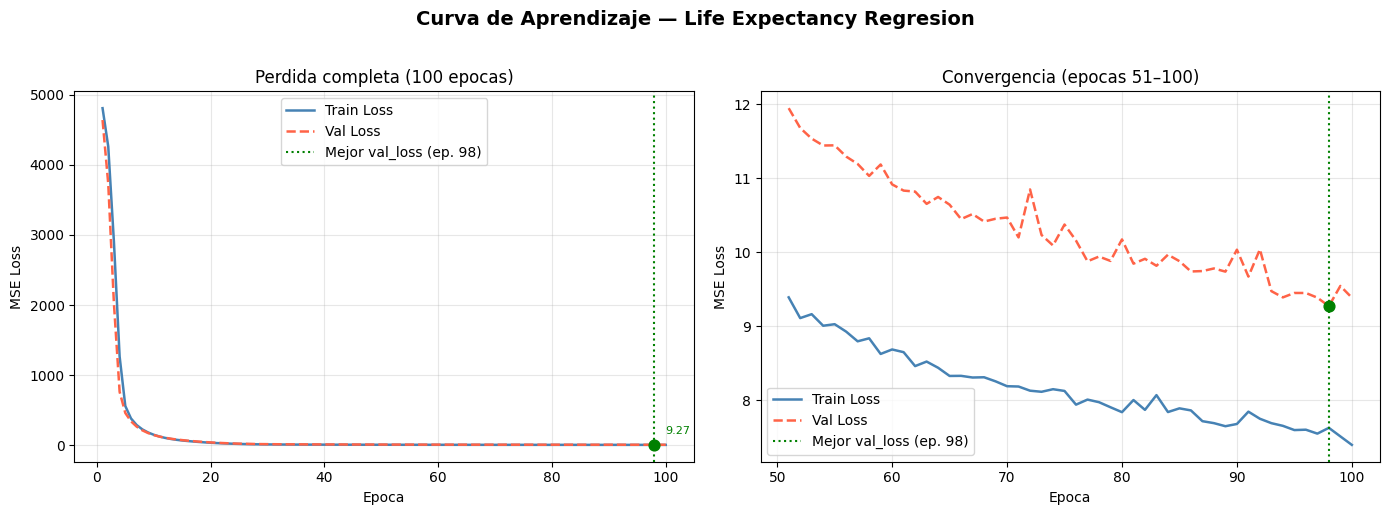

In [34]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Curva de Aprendizaje — Life Expectancy Regresion",
             fontsize=14, fontweight="bold", y=1.02)

# ── Gráfico izquierdo: perdida completa ──────────────────────────────────────
axes[0].plot(epochs_range, train_losses, label="Train Loss",
             color="steelblue", linewidth=1.8)
axes[0].plot(epochs_range, val_losses,   label="Val Loss",
             color="tomato",    linewidth=1.8, linestyle="--")
# Marca vertical en la epoca con mejor val_loss
axes[0].axvline(best_epoch, color="green", linestyle=":", linewidth=1.5,
                label=f"Mejor val_loss (ep. {best_epoch})")
axes[0].scatter([best_epoch], [best_val_loss], color="green", zorder=5, s=60)
axes[0].annotate(f"{best_val_loss:.2f}",
                 xy=(best_epoch, best_val_loss),
                 xytext=(8, 8), textcoords="offset points",
                 fontsize=8, color="green")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title(f"Perdida completa ({len(train_losses)} epocas)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Gráfico derecho: convergencia (segunda mitad de epocas) ──────────────────
mid = len(train_losses) // 2
ep_right = list(epochs_range)[mid:]
axes[1].plot(ep_right, train_losses[mid:], label="Train Loss",
             color="steelblue", linewidth=1.8)
axes[1].plot(ep_right, val_losses[mid:],   label="Val Loss",
             color="tomato",    linewidth=1.8, linestyle="--")
if best_epoch > ep_right[0]:
    axes[1].axvline(best_epoch, color="green", linestyle=":", linewidth=1.5,
                    label=f"Mejor val_loss (ep. {best_epoch})")
    axes[1].scatter([best_epoch], [best_val_loss], color="green", zorder=5, s=60)
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("MSE Loss")
axes[1].set_title(f"Convergencia (epocas {ep_right[0]}–{ep_right[-1]})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 🧪 Paso 11 — Evaluación en el conjunto de prueba

In [35]:
model.eval()
test_loss  = 0.0
all_preds  = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        test_loss += loss.item()
        all_preds.append(y_pred.cpu())
        all_labels.append(y_batch.cpu())

avg_test_loss = test_loss / len(test_loader)
test_rmse     = avg_test_loss ** 0.5

all_preds  = torch.cat(all_preds).numpy().flatten()
all_labels = torch.cat(all_labels).numpy().flatten()
test_mae   = float(np.mean(np.abs(all_preds - all_labels)))

# R²: proporcion de varianza de y explicada por el modelo.
# R²=1 → prediccion perfecta | R²=0 → el modelo no mejora predecir la media.
ss_res = float(np.sum((all_labels - all_preds) ** 2))
ss_tot = float(np.sum((all_labels - all_labels.mean()) ** 2))
test_r2 = 1 - ss_res / ss_tot

print("=" * 40)
print("  RESULTADOS EN CONJUNTO DE PRUEBA")
print("=" * 40)
print(f"  Mejor epoca (val)   : {best_epoch}/{EPOCHS}")
print(f"  Mejor val_loss      : {best_val_loss:.4f}")
print(f"  MSE  (perdida)      : {avg_test_loss:.4f}")
print(f"  RMSE                : {test_rmse:.4f}  anios")
print(f"  MAE                 : {test_mae:.4f}  anios")
print(f"  R2                  : {test_r2:.4f}")
print("=" * 40)

  RESULTADOS EN CONJUNTO DE PRUEBA
  Mejor epoca (val)   : 98/100
  Mejor val_loss      : 9.2714
  MSE  (perdida)      : 9.6561
  RMSE                : 3.1074  anios
  MAE                 : 2.1063  anios
  R2                  : 0.9000


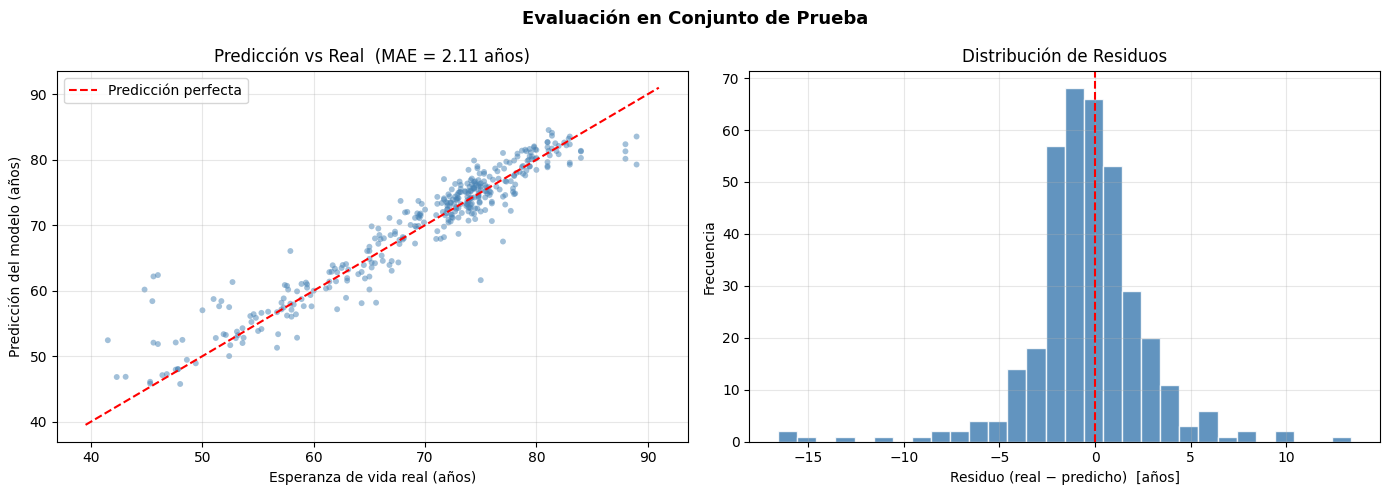

In [36]:
# Gráfico predicciones vs valores reales + distribución de residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evaluación en Conjunto de Prueba",
             fontsize=13, fontweight="bold")

# ── Scatter: predicciones vs reales ──────────────────────────────────────────
lims = [all_labels.min() - 2, all_labels.max() + 2]
axes[0].scatter(all_labels, all_preds, alpha=0.5, color="steelblue", edgecolors="none", s=18)
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Esperanza de vida real (años)")
axes[0].set_ylabel("Predicción del modelo (años)")
axes[0].set_title(f"Predicción vs Real  (MAE = {test_mae:.2f} años)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Distribución de residuos ──────────────────────────────────────────────────
residuals = all_labels - all_preds
axes[1].hist(residuals, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Residuo (real − predicho)  [años]")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de Residuos")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## 📊 Resumen final

| Métrica | Valor |
|---------|-------|
| Conjunto de entrenamiento | 65% |
| Conjunto de validación | 20% |
| Conjunto de prueba | 15% |
| Arquitectura | Input(5) → 64 → ReLU → 32 → ReLU → 1 |
| Épocas máximas | 100 (`EARLY_STOPPING=True`, patience=15) |
| Batch size | 32 |
| Learning rate | 0.001 |
| Weight decay | 0.01 |
| Función de pérdida | MSE (Mean Squared Error) |
| Optimizador | Adam |

### Interpretación de resultados

**Curva de aprendizaje:** Ambas pérdidas (train y val) descienden rápidamente en las primeras
~30 épocas y luego se estabilizan, convergiendo a valores similares. Que la pérdida de
validación **no diverja** respecto a la de entrenamiento es la señal clave de ausencia de
sobreajuste; el `weight_decay=0.01` contribuye activamente a mantener este comportamiento.

**MSE / RMSE / MAE:** Un RMSE de ~3.1 años indica que el error cuadrático medio se sitúa en
torno a 3 años en la escala original. El MAE de ~2.1 años (menos sensible a outliers) confirma
que la mayoría de las predicciones se desvían menos de 2 años respecto al valor real, lo cual
es razonable dado que solo se usan 5 de las 22 características disponibles.

**R²:** Un valor cercano a 0.85–0.90 indica que el modelo explica entre el 85% y el 90% de la
varianza de la esperanza de vida en el conjunto de prueba. Complementa al RMSE/MAE al dar
una perspectiva relativa: dos modelos con el mismo RMSE pueden tener R² muy distintos
dependiendo de la varianza de los datos.

**Residuos:** La distribución de residuos centrada en 0 y aproximadamente simétrica indica
que el modelo no presenta sesgos sistemáticos; no sobreestima ni subestima de forma consistente.
Una cola más larga hacia valores negativos sugeriría tendencia a sobreestimar en países con
esperanza de vida muy baja.